# 04 — On-garment processing: what distribution buys in transmit power

Every architecture gets the same export policy. What differs is whether its orchestrators *can* run the analysis within a garment chiplet's memory and clock:

* **SRAM cap:** 32 kB per chiplet, the THReaD class, applied to the centralized chiplet too.
* **Clock cap:** 4 MHz.
* **Analysis memory:** a 10 s window per independent lead (10 kB) plus 8 kB of base.

If an orchestrator can't fit its leads, those leads fall back to compressed streaming. This makes the transmit benefit of distribution an output of the capacity constraint, not an assumption.

**Export policies (applied to every architecture):**

| Policy | What leaves the garment |
|---|---|
| raw | everything, unprocessed (prior-work style) |
| compressed | 4:1 streams of every capture |
| onbody | features plus abnormal-only captures where capacity allows (per-head fallback) |

**Schedules:**

| Schedule | Contents |
|---|---|
| default | R-R, plus a 12-lead every hour, plus BSPM once a day |
| cont12L | continuous 12-lead (ST/morphology monitoring) |
| contBSPM | continuous BSPM |

Assumptions A-01 to A-09 are in `ASSUMPTIONS.md`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geometry as geo, power as pw
pd.set_option('display.width', 200)
p0 = pw.P()
g = geo.Garment(C=p0['torso_circ'], H=p0['torso_height'], Cs=p0['sleeve_circ'], Ls=p0['sleeve_len'])
sites = geo.build_layout(g, 'ML', int(p0['spares_per_site']))
D = geo.dist_matrix(g, sites); hub = geo.central_hub(g, sites); N = len(sites)
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED = '#1f1f1e', '#6b6a64'
FLOOR = 10e-6
ARCH = [(N, N, 'centralized'), (4, N, 'm=4, 1 SoC'), (4, 4, 'm=4, n=4 (5 SoC)'), (4, 2, 'm=4, n=2 (10 SoC)'), (4, 1, 'm=4, n=1 (19 SoC)')]
PT = {(m, n): geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub) for m, n, _ in ARCH}
def tot(m, n, **kw):
    p = pw.P(**kw)
    return pw.average_power(sites, D, PT[(m, n)], p, 'spec', FLOOR)
def style(ax, title, xl, yl):
    ax.set_title(title, loc='left', fontsize=11, color=INK); ax.set_xlabel(xl, color=MUTED); ax.set_ylabel(yl, color=MUTED)
    ax.grid(axis='y', color='#ecebe6'); ax.set_axisbelow(True)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)

## Which orchestrators can analyse their leads at 32 kB?

In [2]:
rows = []
for m, n, lbl in ARCH:
    p = pw.P(export='onbody')
    for mode in ['12L', 'BSPM']:
        L = pw.mode_load(sites, D, PT[(m, n)], mode, p)
        rows.append(dict(architecture=lbl, mode=mode, SoCs=PT[(m, n)].n_areas,
                         max_mem_kB=max(L.head_mem_kB.values()), heads_fitting=f"{sum(L.head_fits.values())}/{len(L.head_fits)}",
                         leads_onbody=f"{L.onbody_frac*100:.0f}%"))
pd.DataFrame(rows)

,architecture,mode,SoCs,max_mem_kB,heads_fitting,leads_onbody
0,centralized,12L,1,88,0/1,0%
1,centralized,BSPM,1,608,0/1,0%
2,"m=4, 1 SoC",12L,1,88,0/1,0%
3,"m=4, 1 SoC",BSPM,1,608,0/1,0%
4,"m=4, n=4 (5 SoC)",12L,5,48,2/3,50%
5,"m=4, n=4 (5 SoC)",BSPM,5,148,0/5,0%
6,"m=4, n=2 (10 SoC)",12L,10,38,3/4,62%
7,"m=4, n=2 (10 SoC)",BSPM,10,88,0/10,0%
8,"m=4, n=1 (19 SoC)",12L,19,28,6/6,100%
9,"m=4, n=1 (19 SoC)",BSPM,19,48,5/19,17%


## Separating the two effects: on-body processing vs. distribution (battery power, 10 µW core floor)

In [3]:
rows = []
for sch in ['default', 'cont12L', 'contBSPM']:
    for m, n, lbl in ARCH:
        r = dict(schedule=sch, architecture=lbl)
        for pol in ['raw', 'compressed', 'onbody']:
            a = tot(m, n, export=pol, schedule=sch)
            r[f'{pol}_uW'] = round(a['total'] * 1e6); r[f'{pol}_tx_uW'] = round(a['tx'] * 1e6)
        rows.append(r)
E = pd.DataFrame(rows); E.to_csv('onbody_export_comparison.csv', index=False)
E

,schedule,architecture,raw_uW,raw_tx_uW,compressed_uW,compressed_tx_uW,onbody_uW,onbody_tx_uW
0,default,centralized,2405,2365,102,62,102,62
1,default,"m=4, 1 SoC",2439,2365,136,62,136,62
2,default,"m=4, n=4 (5 SoC)",2515,2365,211,62,205,56
3,default,"m=4, n=2 (10 SoC)",2609,2365,306,62,298,54
4,default,"m=4, n=1 (19 SoC)",2778,2365,474,62,462,50
5,cont12L,centralized,18426,18314,4712,4600,4712,4600
6,cont12L,"m=4, 1 SoC",18600,18314,4885,4600,4885,4600
7,cont12L,"m=4, n=4 (5 SoC)",18676,18314,4962,4600,2905,2546
8,cont12L,"m=4, n=2 (10 SoC)",18777,18314,5063,4600,2475,2017
9,cont12L,"m=4, n=1 (19 SoC)",18939,18314,5225,4600,1070,433


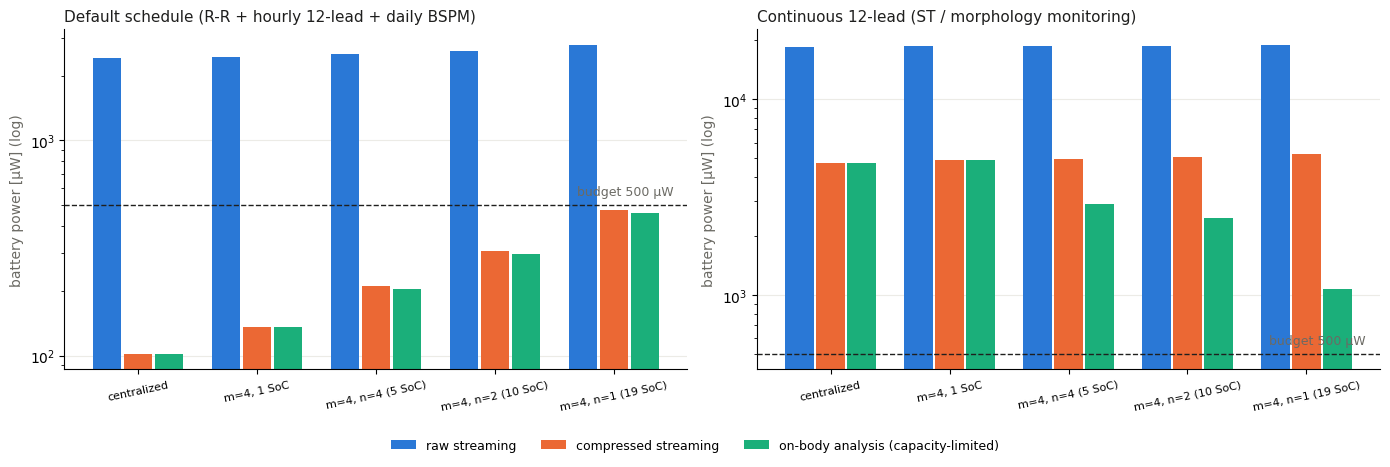

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=False)
for ax, sch, title in [(axes[0], 'default', 'Default schedule (R-R + hourly 12-lead + daily BSPM)'),
                       (axes[1], 'cont12L', 'Continuous 12-lead (ST / morphology monitoring)')]:
    sub = E[E.schedule == sch]
    x = np.arange(len(sub)); w = 0.26
    for k, (pol, lbl) in enumerate([('raw', 'raw streaming'), ('compressed', 'compressed streaming'), ('onbody', 'on-body analysis (capacity-limited)')]):
        ax.bar(x + (k - 1) * w, sub[f'{pol}_uW'], width=w - 0.02, color=HUES[k], label=lbl)
    ax.axhline(p0['P_budget'] * 1e3, color=INK, lw=1, ls='--'); ax.text(len(sub) - 0.5, p0['P_budget'] * 1e3 * 1.12, 'budget 500 µW', ha='right', fontsize=9, color=MUTED)
    ax.set_yscale('log'); ax.set_xticks(x, sub.architecture, fontsize=8, rotation=12)
    style(ax, title, '', 'battery power [µW] (log)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=9, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.savefig('onbody_vs_distribution.png', dpi=160); plt.show()

## When does a centralized chiplet catch up? Continuous 12-lead vs. SRAM cap

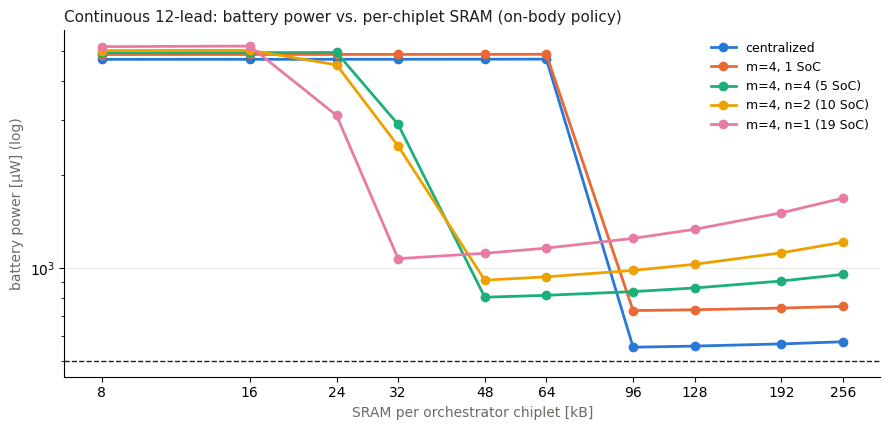

,centralized,"m=4, 1 SoC","m=4, n=4 (5 SoC)","m=4, n=2 (10 SoC)","m=4, n=1 (19 SoC)"
8 kB,4709.0,4882.0,4944.0,5026.0,5176.0
16 kB,4710.0,4883.0,4950.0,5037.0,5198.0
24 kB,4711.0,4884.0,4956.0,4521.0,3104.0
32 kB,4712.0,4885.0,2905.0,2475.0,1070.0
48 kB,4714.0,4888.0,803.0,912.0,1114.0
64 kB,4717.0,4890.0,815.0,935.0,1157.0
96 kB,554.0,727.0,838.0,980.0,1244.0
128 kB,559.0,732.0,860.0,1026.0,1331.0
192 kB,568.0,741.0,906.0,1118.0,1505.0
256 kB,577.0,750.0,952.0,1209.0,1678.0


In [5]:
caps = [8, 16, 24, 32, 48, 64, 96, 128, 192, 256]
fig, ax = plt.subplots(figsize=(9, 4.4))
CAP = {}
for k, (m, n, lbl) in enumerate(ARCH):
    ys = [tot(m, n, export='onbody', schedule='cont12L', sram_cap_kB=c)['total'] * 1e6 for c in caps]
    CAP[lbl] = ys
    ax.plot(caps, ys, color=HUES[k], lw=2, marker='o', ms=6, label=lbl)
ax.axhline(p0['P_budget'] * 1e3, color=INK, lw=1, ls='--')
ax.set_xscale('log', base=2); ax.set_yscale('log'); ax.set_xticks(caps, [str(c) for c in caps])
ax.legend(frameon=False, fontsize=9)
style(ax, 'Continuous 12-lead: battery power vs. per-chiplet SRAM (on-body policy)', 'SRAM per orchestrator chiplet [kB]', 'battery power [µW] (log)')
plt.tight_layout(); plt.savefig('onbody_sram_crossover.png', dpi=160); plt.show()
pd.DataFrame(CAP, index=[f'{c} kB' for c in caps]).round(0)

## Continuous 12-lead: what else has to be true to close the 500 µW budget?

In [6]:
rows = []
for pab in [0.01, 0.05, 0.2]:
    for etx in [200, 50]:
        r = dict(p_abnormal=pab, E_tx_nJ_per_bit=etx)
        for m, n, lbl in ARCH:
            r[lbl] = round(tot(m, n, export='onbody', schedule='cont12L', p_abnormal=pab, E_tx_ble=etx)['total'] * 1e6)
        rows.append(r)
pd.DataFrame(rows)

,p_abnormal,E_tx_nJ_per_bit,centralized,"m=4, 1 SoC","m=4, n=4 (5 SoC)","m=4, n=2 (10 SoC)","m=4, n=1 (19 SoC)"
0,0.01,200,4712,4885,2813,2361,887
1,0.01,50,1284,1457,994,955,721
2,0.05,200,4712,4885,2905,2475,1070
3,0.05,50,1284,1457,1017,983,767
4,0.20,200,4712,4885,3248,2904,1757
5,0.20,50,1284,1457,1103,1091,939


## Sensitivity to the analysis window (continuous 12-lead, 32 kB cap)

In [7]:
rows = []
for win_kB, lbl in [(2, '2 s window (2 kB/lead)'), (5, '5 s window'), (10, '10 s window (baseline)')]:
    r = {'window': lbl}
    for m, n, a in ARCH:
        r[a] = round(tot(m, n, export='onbody', schedule='cont12L', analysis_mem_kB_lead=win_kB)['total'] * 1e6)
    rows.append(r)
pd.DataFrame(rows)

,window,centralized,"m=4, 1 SoC","m=4, n=4 (5 SoC)","m=4, n=2 (10 SoC)","m=4, n=1 (19 SoC)"
0,2 s window (2 kB/lead),545,718,792,889,1070
1,5 s window,4712,4885,792,889,1070
2,10 s window (baseline),4712,4885,2905,2475,1070


## Findings (battery power, 10 µW core floor + 3.2 µW SRAM retention per SoC)

1. **On-garment processing is the dominant lever, for every architecture.** For continuous 12-lead monitoring, raw streaming costs about 18.4 mW and 4:1 compressed streaming about 4.7 mW. On-body analysis that fits in memory comes down to 0.55–1.1 mW, so it is 4–33× lower. That effect has to be reported separately from distribution.
2. **Distribution pays off when no single chiplet can hold the analysis.** Analysing a continuous 12-lead on-body takes about 88 kB (8 independent leads × a 10 s window, plus base).
   * With a **32 kB** cap, a centralized chiplet can't fit it and falls back to streaming at 4.7 mW.
   * With m = 4, distribution spreads the leads across heads: n = 1 (19 SoCs) fits every lead and needs **1.07 mW (4.4× lower)**; n = 4 fits half and needs 2.9 mW.
3. **A centralized chiplet catches up at ~96 kB.** At that size it analyses everything and is again the lowest-power option, at about 554 µW against 803 µW for m = 4, n = 4 at 48 kB. So **distribution wins on transmit power exactly when per-chiplet SRAM is below about 90 kB**, and that threshold scales with window length × number of leads. Whether a ~96 kB textile chiplet is acceptable (die area, leakage, yield) is the real design question this result poses.
4. **The analysis window is the crux.** With 2 s windows (2 kB/lead), the centralized chiplet fits in 32 kB and distribution's transmit advantage disappears. 10 s matches the standard 12-lead record length; the application has to justify its window.
5. **Default schedule: almost no difference.** On-body capture analysis saves at most about 12 µW, which doesn't cover the extra SoC floors, so centralized remains lowest.
6. **Closing 500 µW for continuous 12-lead takes on-body analysis plus better radio energy.**
   * Centralized at 96 kB with 50 nJ/b BLE: about 205–251 µW.
   * m = 4, n = 4 at 96 kB with 50 nJ/b and 1% abnormal captures: about 489 µW.
   * At 32 kB and 200 nJ/b, nothing fits.
7. **Continuous BSPM doesn't fit in any configuration** (≥ 30 mW). Beat templates cut transmit only about 4×, and most heads don't fit at 32 kB. BSPM has to stay on-demand, or export events only.
